En este trabajo se estudia el problema de contorno no lineal, dado por:
		$$T''(x)-\sigma^2 (T(x)) T(x)=-f(x) \ , \ 0<x<L$$
		$$T'(0)=\beta T(0)-\gamma $$
		$$T(L)=\delta $$
		$$f(x)=F_0 e^{-\mu x}$$
donde $\sigma^2(T)$ es una función tipo sigmoide:
$$	\sigma^2(T) = \sigma_{\min}^2 + \frac{\sigma_{\max}^2 - \sigma_{\min}^2}{1 + e^{-k(T - T_c)}}
$$
donde $\sigma_{\min}^2$ y $\sigma_{\max}^2$ representan los valores asintóticos del coeficiente a bajas y altas temperaturas, respectivamente, $T_c$ representa la temperatura crítica de transición, y $k$ define la sensibilidad o pendiente del cambio de fase.
Se propone el esquema de diferencias finitas de segundo orden con nodo fantasma. La ecuació resultante se resuelve mediante el método de aproximaciones sucesivas de Picard.

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


 INICIANDO ITERACIÓN DE PICARD CON RELAJACIÓN 
¡Convergencia alcanzada en la iteración 113! Error final: 9.711746051799253e-7


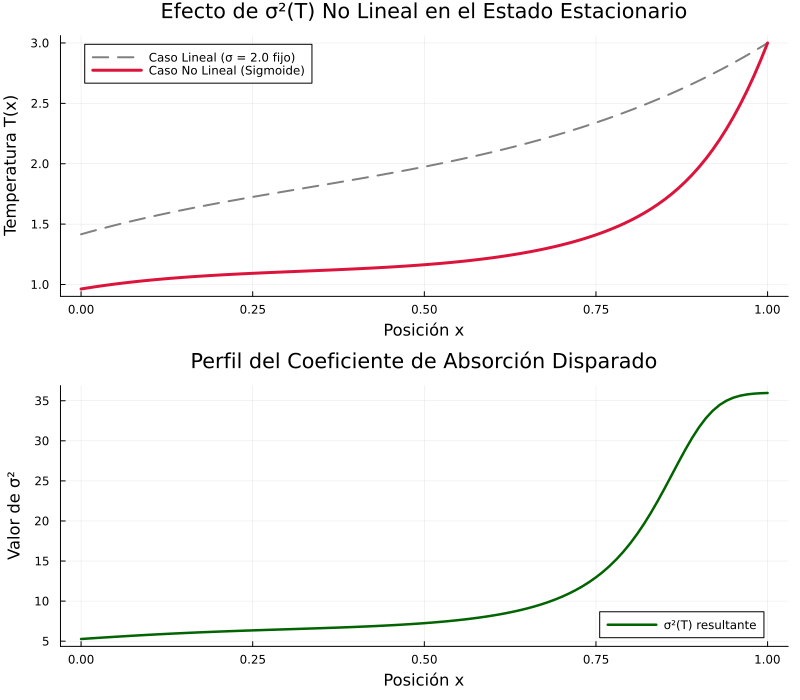

In [7]:
# ==========================================
# PREPARACIÓN DEL ENTORNO
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using LinearAlgebra
using Plots

function simular_estacionario_no_lineal()
    # =================================================================
    # 1. PARÁMETROS GEOMÉTRICOS, FUENTE Y FRONTERAS
    # =================================================================
    L, β, γ, δ = 1.0, 1.5, 0.5, 3.0
    F0, μ = 10.0, 1.0
    
    # PARAMETRIZACIÓN DE LA SIGMOIDE para σ²(T)
    σ2_min = 2.0^2  
    σ2_max = 6.0^2  
    Tc = 1.6        
    k_sig = 5.0     
    
    calcular_σ2(T) = σ2_min + (σ2_max - σ2_min) / (1.0 + exp(-k_sig * (T - Tc)))

    # Discretización espacial
    N = 100
    dx = L / N
    x_nodos = collect(0:dx:L)
    f(x) = F0 * exp(-μ * x)

    # =================================================================
    # 2. BUCLE DE PICARD CON SUB-RELAJACIÓN (RESOLUCIÓN NO LINEAL)
    # =================================================================
    ω_relajacion = 0.1  
    T_actual = fill(1.5, N) 
    T_nueva = zeros(N)
    
    tol = 1e-6
    max_iter = 500  
    iter = 0
    convergido = false

    dv = zeros(N)
    ev = zeros(N - 1)
    b = zeros(N)

    println("="^50)
    println(" INICIANDO ITERACIÓN DE PICARD CON RELAJACIÓN ")
    println("="^50)

    while !convergido && iter < max_iter
        iter += 1
        
        σ2_local = calcular_σ2.(T_actual)

        # Reconstruir operador tridiagonal (Nodo Fantasma)
        dv[1] = -(1/dx^2 + β/dx + σ2_local[1]/2)
        ev[1] = 1/dx^2
        b[1] = -f(0)/2 - γ/dx

        for i in 2:N-1
            xi = (i-1) * dx
            dv[i] = -(2/dx^2 + σ2_local[i])
            ev[i] = 1/dx^2
            b[i] = -f(xi)
        end

        dv[N] = -(2/dx^2 + σ2_local[N])
        b[N] = -f((N-1)*dx) - δ/dx^2

        # Resolver paso lineal
        A_sym = SymTridiagonal(dv, ev)
        T_calculada = A_sym \ b

        # Aplicar sub-relajación
        T_nueva = ω_relajacion .* T_calculada .+ (1.0 - ω_relajacion) .* T_actual

        error_norm = norm(T_nueva - T_actual, Inf)
        
        if error_norm < tol
            convergido = true
            println("¡Convergencia alcanzada en la iteración ", iter, "! Error final: ", error_norm)
        else
            T_actual = copy(T_nueva) 
        end
    end
    
    if !convergido
        println("⚠️ Advertencia: No se alcanzó la tolerancia en $max_iter iteraciones.")
    end

    T_final_no_lineal = [T_nueva; δ]

    # =================================================================
    # 3. CÁLCULO DEL CASO LINEAL PARA COMPARATIVA
    # =================================================================
    dv_lin = [i == 1 ? -(1/dx^2 + β/dx + 2.0^2/2) : -(2/dx^2 + 2.0^2) for i in 1:N]
    ev_lin = fill(1/dx^2, N-1)
    
    b_lin = zeros(N)
    b_lin[1] = -f(0)/2 - γ/dx
    for i in 2:N-1
        b_lin[i] = -f((i-1)*dx)
    end
    b_lin[N] = -f((N-1)*dx) - δ/dx^2

    A_lin = SymTridiagonal(dv_lin, ev_lin)
    T_lineal = [A_lin \ b_lin; δ]

    # =================================================================
    # 4. GRAFICACIÓN DE RESULTADOS CORREGIDA
    # =================================================================
    # Pasamos grid=true directamente como propiedad del gráfico
    p1 = plot(x_nodos, T_lineal, lw=2, color=:gray, ls=:dash, label="Caso Lineal (σ = 2.0 fijo)", grid=true)
    plot!(p1, x_nodos, T_final_no_lineal, lw=3, color=:crimson, label="Caso No Lineal (Sigmoide)")
    title!(p1, "Efecto de σ²(T) No Lineal en el Estado Estacionario")
    xlabel!(p1, "Posición x")
    ylabel!(p1, "Temperatura T(x)")

    σ2_final = calcular_σ2.(T_final_no_lineal)
    p2 = plot(x_nodos, σ2_final, lw=2.5, color=:darkgreen, label="σ²(T) resultante", legend=:bottomright, grid=true)
    title!(p2, "Perfil del Coeficiente de Absorción Disparado")
    xlabel!(p2, "Posición x")
    ylabel!(p2, "Valor de σ²")

    plot(p1, p2, layout=(2,1), size=(800, 700))
end

simular_estacionario_no_lineal()